## Data Cleaning

In [105]:
import pandas as pd

In [106]:
ARTS = "artifacts_v1"  

df = pd.read_csv(f"{ARTS}/df.csv")
df_supervised = pd.read_csv(f"{ARTS}/df_supervised.csv")
df_unsupervised = pd.read_csv(f"{ARTS}/df_unsupervised.csv")

print("Loaded successfully:")
print(f"df shape: {df.shape}")
print(f"df_supervised shape: {df_supervised.shape}")
print(f"df_unsupervised shape: {df_unsupervised.shape}")

display(df.head(3))

/var/folders/c7/mwgyyxds33bg8rksxm07_r_00000gn/T/ipykernel_16228/2333722459.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{ARTS}/df.csv")
/var/folders/c7/mwgyyxds33bg8rksxm07_r_00000gn/T/ipykernel_16228/2333722459.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_unsupervised = pd.read_csv(f"{ARTS}/df_unsupervised.csv")


Loaded successfully:
df shape: (261988, 39)
df_supervised shape: (237851, 30)
df_unsupervised shape: (261988, 39)


,code,creator,product_name,brands,brands_tags,countries,countries_en,ingredients_text,serving_size,additives_n,...,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,grade_num
0,4530,usda-ndb-import,Banana Chips Sweetened (Whole),Unknown,unknown,US,united states,"Bananas, vegetable oil (coconut oil, corn oil ...",28 g (1 ONZ),0.0,...,3.57,0.00000,0.000,0.0,0.0214,0.000,0.00129,14.0,14.0,2.0
1,4559,usda-ndb-import,Peanuts,torn & glasser,torn-glasser,US,united states,"Peanuts, wheat flour, sugar, rice flour, tapio...",28 g (0.25 cup),0.0,...,17.86,0.63500,0.250,0.0,0.0000,0.071,0.00129,0.0,0.0,4.0
2,16087,usda-ndb-import,Organic Salted Nut Mix,grizzlies,grizzlies,US,united states,"Organic hazelnuts, organic cashews, organic wa...",28 g (0.25 cup),0.0,...,17.86,1.22428,0.482,0.0,0.0000,0.143,0.00514,12.0,12.0,2.0


In [107]:
cat_cols = ['brands_tags', 'countries_en', 'additives_tags', 'pnns_groups_1', 'pnns_groups_2']

for col in cat_cols:
    print(f"{col}: {df_supervised[col].nunique()} unique values")

brands_tags: 39299 unique values
countries_en: 560 unique values
additives_tags: 34221 unique values
pnns_groups_1: 15 unique values
pnns_groups_2: 42 unique values


### Supervised Learning Model

In [108]:
for col in df_supervised.columns:
    print(col)

product_name
brands_tags
countries_en
ingredients_text
serving_size
additives_n
additives_tags
ingredients_from_palm_oil_n
ingredients_that_may_be_from_palm_oil_n
nutrition_grade_fr
pnns_groups_1
pnns_groups_2
energy_100g
fat_100g
saturated-fat_100g
trans-fat_100g
cholesterol_100g
carbohydrates_100g
sugars_100g
fiber_100g
proteins_100g
salt_100g
sodium_100g
vitamin-a_100g
vitamin-c_100g
calcium_100g
iron_100g
nutrition-score-fr_100g
nutrition-score-uk_100g
grade_num


In [109]:
cols_to_drop = [
    'product_name', 'nutrition-score-fr_100g', 'nutrition-score-uk_100g'
]
df_supervised = df_supervised.drop(columns=cols_to_drop)

#### Encoding

In [110]:
non_numeric_cols = df_supervised.select_dtypes(exclude=['number']).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: ['brands_tags', 'countries_en', 'ingredients_text', 'serving_size', 'additives_tags', 'nutrition_grade_fr', 'pnns_groups_1', 'pnns_groups_2']


In [111]:
for col in non_numeric_cols:
    print(f"{col}: {df_supervised[col].nunique()} unique values")

brands_tags: 39299 unique values
countries_en: 560 unique values
ingredients_text: 196822 unique values
serving_size: 23245 unique values
additives_tags: 34221 unique values
nutrition_grade_fr: 5 unique values
pnns_groups_1: 15 unique values
pnns_groups_2: 42 unique values


In [112]:
from sklearn.preprocessing import LabelEncoder

df_enc = df_supervised.copy()

drop_cols = ['ingredients_text', 'serving_size', 'nutrition_grade_fr',
             'sodium_100g']
df_enc.drop(columns=[c for c in drop_cols if c in df_enc.columns], inplace=True, errors='ignore')

Prior to modeling, a few features were dropped to reduce the dataset to only relevant predictive variables to nutritional quality. For example, product_name, ingredients_text, and serving_size did not meet the criteria for a predictive variable, as these are identifiers, unstructured text, or redundant when nutrients can be reported per 100g. The latter is the case for the nutrition_grade_fr variable because the numeric version is dependent variable (grade_num). Moreover, nutrition-score-fr_100g and nutrition-score-uk_100g were dropped to prevent data leakage, as the indicators go into calculating the nutrition grade. Lastly, sodium_100g was removed due to it having a high correlation with salt_100g, which was kept for future use, and it also is interpretable. By removing these features, the model learns from distinct meaningful nutritional, additive, and categorical features that do not have redundancy or indications of data leakage as a variable.

#### High-Cardinality

In [113]:
for col in ['brands_tags', 'countries_en']:
    freq_map = df_enc[col].value_counts(normalize=True)
    df_enc[col] = df_enc[col].map(freq_map)

#### Count Encoding for Addtive Tags

In [114]:
df_enc['additives_count'] = df_enc['additives_tags'].fillna('').apply(lambda x: len(str(x).split(',')) if x != '' else 0)
df_enc.drop(columns='additives_tags', inplace=True, errors='ignore')

#### One-Hot Encoding

In [115]:
df_enc = pd.get_dummies(df_enc, columns=['pnns_groups_1'], prefix='group1', drop_first=True)

#### Label Encoding

In [116]:
le = LabelEncoder()
df_enc['pnns_groups_2'] = df_enc['pnns_groups_2'].astype(str)
df_enc['pnns_groups_2'] = le.fit_transform(df_enc['pnns_groups_2'])

In [117]:
df_supervised = df_enc.copy()
print(df_supervised.shape)

(237851, 36)


In [118]:
non_numeric_cols = (
    df_supervised.select_dtypes(include=["object", "category"]).columns.tolist()
)

print("Non-numeric cols still present:", non_numeric_cols)

for col in non_numeric_cols:
    print(f"{col:20s} -> {df_supervised[col].nunique()} unique")

print("\nShape:", df_supervised.shape)
print(df_supervised.dtypes.head(20))

Non-numeric cols still present: []

Shape: (237851, 36)
brands_tags                                float64
countries_en                               float64
additives_n                                float64
ingredients_from_palm_oil_n                float64
ingredients_that_may_be_from_palm_oil_n    float64
pnns_groups_2                                int64
energy_100g                                float64
fat_100g                                   float64
saturated-fat_100g                         float64
trans-fat_100g                             float64
cholesterol_100g                           float64
carbohydrates_100g                         float64
sugars_100g                                float64
fiber_100g                                 float64
proteins_100g                              float64
salt_100g                                  float64
vitamin-a_100g                             float64
vitamin-c_100g                             float64
calcium_100g              

### Feature Engineering

In [119]:
import numpy as np

In [120]:
df_fe = df_supervised.copy()

def safe_div(num, den):
    den = den.replace({0: np.nan})
    return num / den

energy_is_kj = df_fe['energy_100g'].median() > 1000  
FAT_E = 37 if energy_is_kj else 9      
PROT_E = 17 if energy_is_kj else 4    

In [121]:
df_fe['fat_to_energy']     = safe_div(df_fe['fat_100g']      * FAT_E,  df_fe['energy_100g']).clip(0, 1)
df_fe['protein_to_energy'] = safe_div(df_fe['proteins_100g'] * PROT_E, df_fe['energy_100g']).clip(0, 1)

df_fe['sugar_to_carb'] = safe_div(df_fe['sugars_100g'], df_fe['carbohydrates_100g']).clip(lower=0)

df_fe['has_additives'] = (df_fe['additives_n'] > 0).astype(int)
df_fe['palm_oil_flag'] = (
    (df_fe['ingredients_from_palm_oil_n'].fillna(0) > 0) |
    (df_fe['ingredients_that_may_be_from_palm_oil_n'].fillna(0) > 0)
).astype(int)

In [122]:
print("New engineered columns:")
print(df_fe[['fat_to_energy','protein_to_energy','sugar_to_carb','has_additives','palm_oil_flag']].describe(percentiles=[.25,.5,.75]).T)

df_supervised = df_fe

New engineered columns:
                      count      mean       std  min       25%       50%  \
fat_to_energy      235600.0  0.336922  0.278054  0.0  0.062290  0.321098   
protein_to_energy  235600.0  0.145051  0.167358  0.0  0.041784  0.092359   
sugar_to_carb      225363.0  0.497633  0.363797  0.0  0.114547  0.500000   
has_additives      237851.0  0.633926  0.481731  0.0  0.000000  1.000000   
palm_oil_flag      237851.0  0.068030  0.251798  0.0  0.000000  0.000000   

                        75%  max  
fat_to_energy      0.537310  1.0  
protein_to_energy  0.187376  1.0  
sugar_to_carb      0.854015  1.0  
has_additives      1.000000  1.0  
palm_oil_flag      0.000000  1.0  


In [123]:
for col in df_supervised.columns:
    print(col)

brands_tags
countries_en
additives_n
ingredients_from_palm_oil_n
ingredients_that_may_be_from_palm_oil_n
pnns_groups_2
energy_100g
fat_100g
saturated-fat_100g
trans-fat_100g
cholesterol_100g
carbohydrates_100g
sugars_100g
fiber_100g
proteins_100g
salt_100g
vitamin-a_100g
vitamin-c_100g
calcium_100g
iron_100g
grade_num
additives_count
group1_Cereals and potatoes
group1_Composite foods
group1_Fat and sauces
group1_Fish Meat Eggs
group1_Fruits and vegetables
group1_Milk and dairy products
group1_Salty snacks
group1_Sugary snacks
group1_Unknown
group1_cereals-and-potatoes
group1_fruits-and-vegetables
group1_salty-snacks
group1_sugary-snacks
group1_unknown
fat_to_energy
protein_to_energy
sugar_to_carb
has_additives
palm_oil_flag


### Feature Engineering

In [124]:
df_check = df_supervised.copy()
numeric_cols = df_check.select_dtypes(include=['float64', 'int64']).columns.tolist()
binary_cols = [c for c in numeric_cols if set(df_check[c].dropna().unique()) <= {0, 1}]
continuous_cols = [c for c in numeric_cols if c not in binary_cols and c != 'grade_num']

dummy_cols = [c for c in df_check.columns if c.startswith('group1_')]

print("Binary features:", binary_cols)
print("\nContinuous features:", continuous_cols)
print("\nDummy features:", dummy_cols)

Binary features: ['has_additives', 'palm_oil_flag']

Continuous features: ['brands_tags', 'countries_en', 'additives_n', 'ingredients_from_palm_oil_n', 'ingredients_that_may_be_from_palm_oil_n', 'pnns_groups_2', 'energy_100g', 'fat_100g', 'saturated-fat_100g', 'trans-fat_100g', 'cholesterol_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'vitamin-a_100g', 'vitamin-c_100g', 'calcium_100g', 'iron_100g', 'additives_count', 'fat_to_energy', 'protein_to_energy', 'sugar_to_carb']

Dummy features: ['group1_Cereals and potatoes', 'group1_Composite foods', 'group1_Fat and sauces', 'group1_Fish Meat Eggs', 'group1_Fruits and vegetables', 'group1_Milk and dairy products', 'group1_Salty snacks', 'group1_Sugary snacks', 'group1_Unknown', 'group1_cereals-and-potatoes', 'group1_fruits-and-vegetables', 'group1_salty-snacks', 'group1_sugary-snacks', 'group1_unknown']


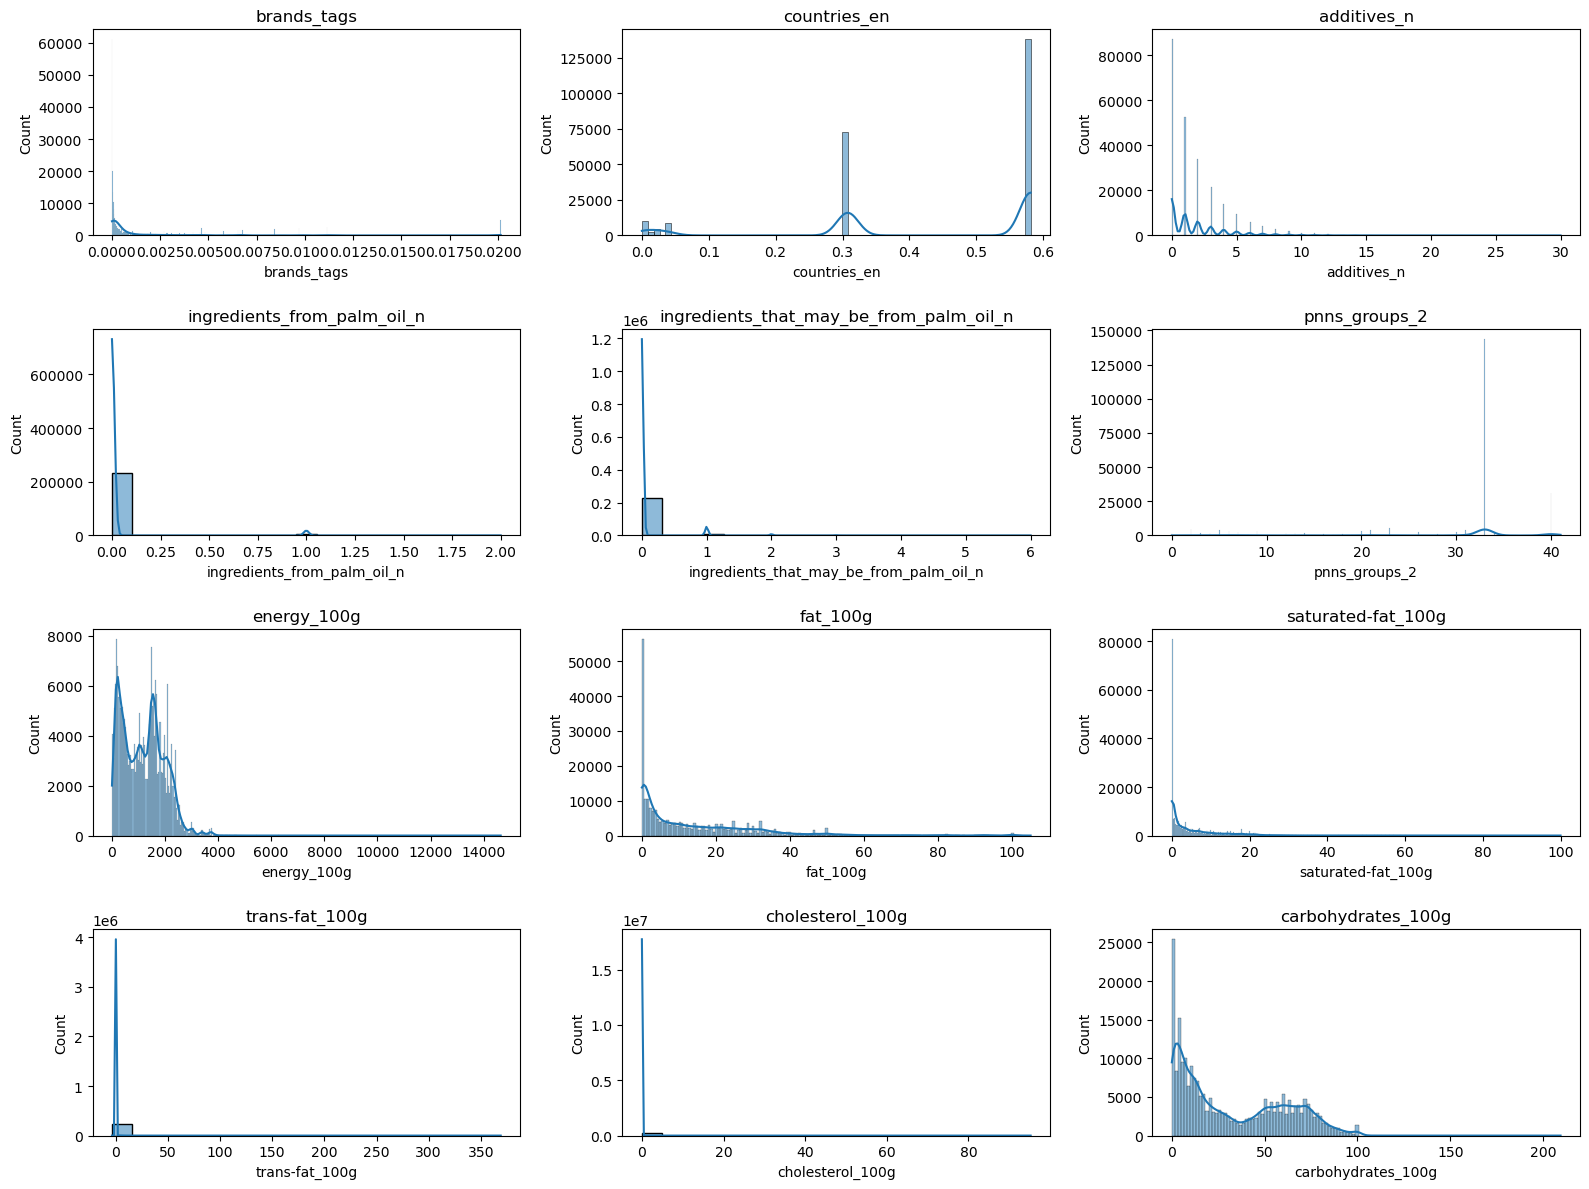

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))
for i, col in enumerate(continuous_cols[:12], 1): 
    plt.subplot(4, 3, i)
    sns.histplot(df_check[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [126]:
summary = df_check[continuous_cols].describe().T
summary['missing_%'] = df_check[continuous_cols].isna().mean() * 100
summary = summary[['count', 'mean', 'std', 'min', 'max', 'missing_%']]
summary.round(2)

,count,mean,std,min,max,missing_%
brands_tags,237851.0,0.00,0.000000e+00,0.00,2.000000e-02,0.00
countries_en,237851.0,0.43,1.900000e-01,0.00,5.800000e-01,0.00
additives_n,237851.0,1.88,2.480000e+00,0.00,3.000000e+01,0.00
ingredients_from_palm_oil_n,237851.0,0.03,1.600000e-01,0.00,2.000000e+00,0.00
ingredients_that_may_be_from_palm_oil_n,237851.0,0.06,2.800000e-01,0.00,6.000000e+00,0.00
pnns_groups_2,237851.0,29.35,1.006000e+01,0.00,4.100000e+01,0.00
energy_100g,237851.0,1172.45,7.671200e+02,0.00,1.464400e+04,0.00
fat_100g,237851.0,13.37,1.631000e+01,0.00,1.050000e+02,0.00
saturated-fat_100g,237851.0,4.90,7.410000e+00,0.00,1.000000e+02,0.00
trans-fat_100g,237851.0,0.04,1.180000e+00,-3.57,3.690000e+02,0.00


In [127]:
df_supervised = df_supervised[df_supervised['fiber_100g'] < 100]  

low_var = df_supervised[['vitamin-a_100g', 'vitamin-c_100g', 'calcium_100g', 'iron_100g']].std()
print(low_var)

drop_low_var = low_var[low_var < 1e-3].index.tolist()
df_supervised.drop(columns=drop_low_var, inplace=True)
print("Dropped near-zero variance columns:", drop_low_var)

vitamin-a_100g    0.001732
vitamin-c_100g    0.326904
calcium_100g      2.111070
iron_100g         0.131746
dtype: float64
Dropped near-zero variance columns: []


/var/folders/c7/mwgyyxds33bg8rksxm07_r_00000gn/T/ipykernel_16228/411933045.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_supervised.drop(columns=drop_low_var, inplace=True)


Prior to fitting our models, we ensured that we standardized the continuous numeric features to put all of the variables on equal footing in contributing to the model. Our dataset contains nutritional measurements that span wide ranges, and often exceptionally large values, with that impact the distribution (i.e., fat, sugar, energy) and therefore the use of a standard scaler, such as StandardScaler, may be distorted by extreme outliers. 


Thus, we applied the RobustScaler which scales the data based on the median value and interquartile range (IQR) instead of the mean/standard deviation. As a result, the scaling process becomes less sensitive to very large outliers being included as part of the feature values, and is more appropriate for analyzing nutritional data where even certain products (e.g., oils or snacks) provided extreme nutrient values compared with the rest of the dataset.


We only scaled the continuous numeric features (e.g., nutrients, derived ratios) and not the binary (has_additives, palm_oil_flag) or dummy-encoded (group1_*) columns since they are categorical indicators and already on a comparable 0-1 scale. 


This scaling enables our model to interpret the importance of the nutrients without the influence from different numeric characteristics dominating the feature importance.

In [128]:
TARGET = "grade_num"

y = df_supervised[TARGET]
X = df_supervised.drop(columns=[TARGET]).copy()

binary_cols = [c for c in ["has_additives", "palm_oil_flag"] if c in X.columns]

dummy_cols = [c for c in X.columns if c.startswith("group1_")]

num_candidates = X.select_dtypes(include="number").columns.tolist()
continuous_cols = sorted(
    set(num_candidates) - set(binary_cols) - set(dummy_cols)
)

print("Will scale:", continuous_cols)
print("Will pass-through (no scale):", binary_cols + dummy_cols)

empty_cont = [c for c in continuous_cols if X[c].notna().sum() == 0]
if empty_cont:
    X.drop(columns=empty_cont, inplace=True)
    continuous_cols = [c for c in continuous_cols if c not in empty_cont]
    print("Dropped empty numeric columns:", empty_cont)

X[continuous_cols] = X[continuous_cols].apply(lambda s: s.fillna(s.median()))

from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

scaler = RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0))

ct = ColumnTransformer(
    transformers=[
        ("robust_scale", scaler, continuous_cols),
        ("passthrough", "passthrough", binary_cols + dummy_cols),
    ],
    remainder="drop",     
    verbose_feature_names_out=False
)

X_scaled_array = ct.fit_transform(X)

final_cols = continuous_cols + binary_cols + dummy_cols

import pandas as pd
X_scaled = pd.DataFrame(X_scaled_array, columns=final_cols, index=X.index)

print("Scaled feature matrix shape:", X_scaled.shape)
print("Sample (first 3 cols):")
print(X_scaled.iloc[:3, :3].round(3))

Will scale: ['additives_count', 'additives_n', 'brands_tags', 'calcium_100g', 'carbohydrates_100g', 'cholesterol_100g', 'countries_en', 'energy_100g', 'fat_100g', 'fat_to_energy', 'fiber_100g', 'ingredients_from_palm_oil_n', 'ingredients_that_may_be_from_palm_oil_n', 'iron_100g', 'pnns_groups_2', 'protein_to_energy', 'proteins_100g', 'salt_100g', 'saturated-fat_100g', 'sugar_to_carb', 'sugars_100g', 'trans-fat_100g', 'vitamin-a_100g', 'vitamin-c_100g']
Will pass-through (no scale): ['has_additives', 'palm_oil_flag', 'group1_Cereals and potatoes', 'group1_Composite foods', 'group1_Fat and sauces', 'group1_Fish Meat Eggs', 'group1_Fruits and vegetables', 'group1_Milk and dairy products', 'group1_Salty snacks', 'group1_Sugary snacks', 'group1_Unknown', 'group1_cereals-and-potatoes', 'group1_fruits-and-vegetables', 'group1_salty-snacks', 'group1_sugary-snacks', 'group1_unknown']
Scaled feature matrix shape: (237836, 40)
Sample (first 3 cols):
  additives_count additives_n brands_tags
0    

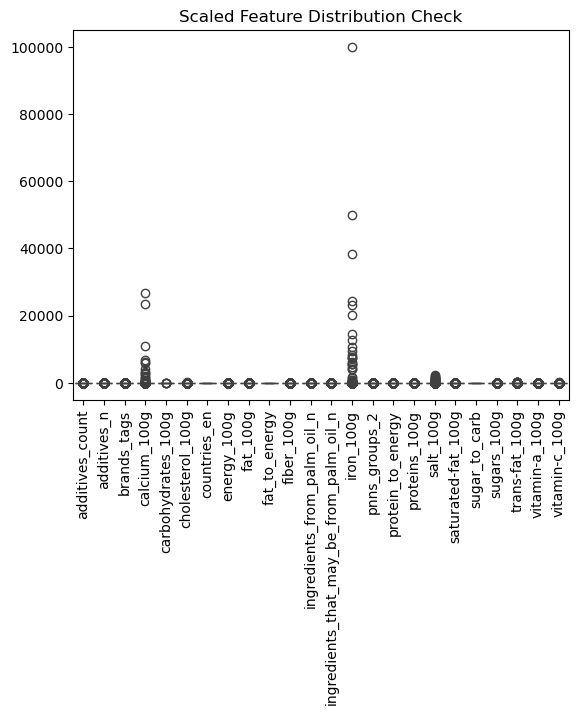

In [129]:
scaled = pd.DataFrame(scaler.fit_transform(df_supervised[continuous_cols]), 
                      columns=continuous_cols)
sns.boxplot(data=scaled)
plt.xticks(rotation=90)
plt.title("Scaled Feature Distribution Check")
plt.show()

These are inflating the scale despite RobustScaler being robust to normal outliers — but not catastrophic ones.

Will scale (continuous): ['additives_count', 'additives_n', 'calcium_100g', 'carbohydrates_100g', 'cholesterol_100g', 'energy_100g', 'fat_100g', 'fat_to_energy', 'fiber_100g', 'ingredients_from_palm_oil_n', 'ingredients_that_may_be_from_palm_oil_n', 'iron_100g', 'protein_to_energy', 'proteins_100g', 'salt_100g', 'saturated-fat_100g', 'sugar_to_carb', 'sugars_100g', 'trans-fat_100g', 'vitamin-a_100g', 'vitamin-c_100g']
Will one-hot (categorical): ['pnns_groups_2']
Will pass-through: ['group1_Cereals and potatoes', 'group1_Composite foods', 'group1_Fat and sauces', 'group1_Fish Meat Eggs', 'group1_Fruits and vegetables', 'group1_Milk and dairy products', 'group1_Salty snacks', 'group1_Sugary snacks', 'group1_Unknown', 'group1_cereals-and-potatoes', 'group1_fruits-and-vegetables', 'group1_salty-snacks', 'group1_sugary-snacks', 'group1_unknown', 'has_additives', 'palm_oil_flag', 'group1_Cereals and potatoes', 'group1_Composite foods', 'group1_Fat and sauces', 'group1_Fish Meat Eggs', 'grou

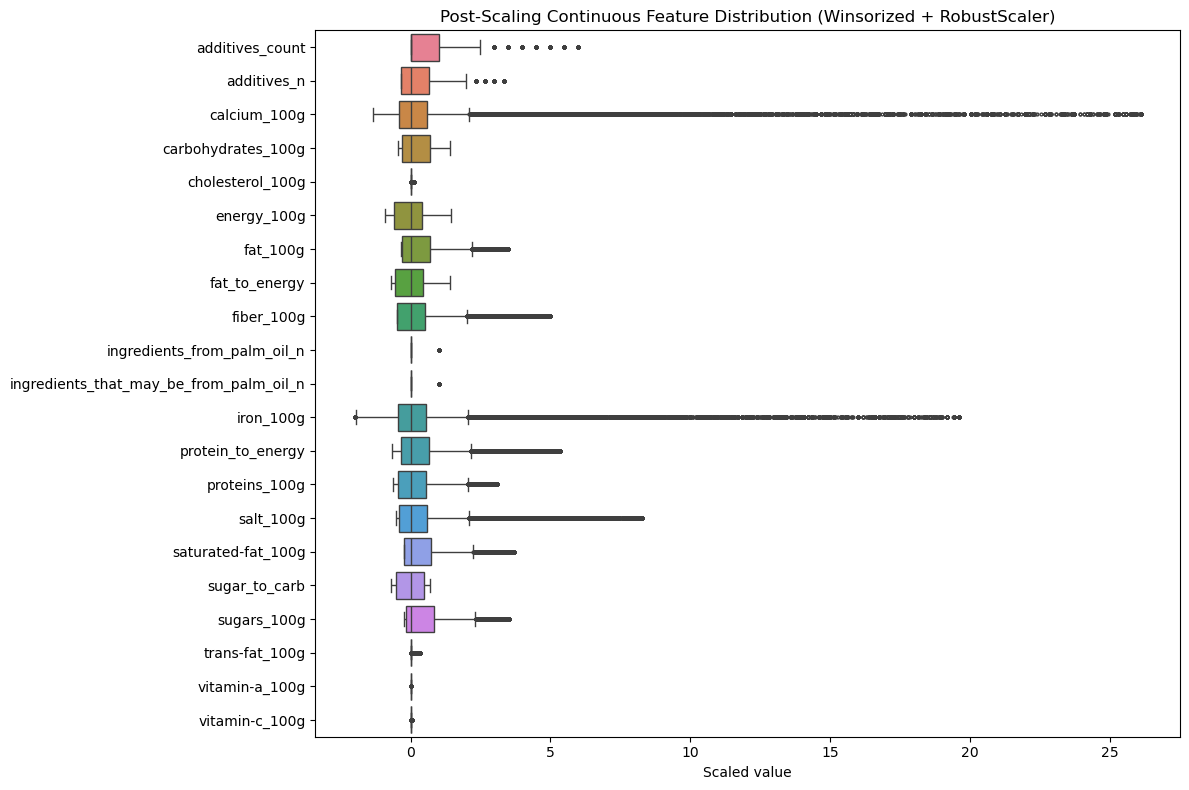

In [130]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

TARGET = "grade_num"
y = df_supervised[TARGET].copy()
X = df_supervised.drop(columns=[TARGET]).copy()

binary_cols = [c for c in X.columns if set(pd.Series(X[c].dropna().unique()).astype(float)) <= {0.0, 1.0}]
dummy_cols  = [c for c in X.columns if c.startswith("group1_")]
cat_cols = ["pnns_groups_2"]
freq_cols = ["brands_tags", "countries_en"]
passthrough_extra = freq_cols

num_cands = X.select_dtypes(include="number").columns.tolist()
continuous_cols = sorted(set(num_cands) - set(binary_cols) - set(dummy_cols) - set(cat_cols) - set(passthrough_extra))

print("Will scale (continuous):", continuous_cols)
print("Will one-hot (categorical):", cat_cols)
print("Will pass-through:", binary_cols + dummy_cols + passthrough_extra)
empty_cont = [c for c in continuous_cols if X[c].notna().sum() == 0]
if empty_cont:
    X.drop(columns=empty_cont, inplace=True)
    continuous_cols = [c for c in continuous_cols if c not in empty_cont]
def winsorize_inplace(df, cols, lo=1.0, hi=99.0):
    for c in cols:
        s = df[c]
        if s.notna().sum() < 10:  # skip tiny columns
            continue
        q_lo, q_hi = np.nanpercentile(s, [lo, hi])
        if not np.isfinite(q_lo) or not np.isfinite(q_hi) or q_lo >= q_hi:
            continue
        df[c] = s.clip(q_lo, q_hi)

winsorize_inplace(X, continuous_cols, lo=1.0, hi=99.0)
X[continuous_cols] = X[continuous_cols].apply(lambda s: s.fillna(s.median()))
ct = ColumnTransformer(
    transformers=[
        ("scale", RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25, 75)), continuous_cols),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("pass", "passthrough", binary_cols + dummy_cols + passthrough_extra),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_scaled = ct.fit_transform(X)
oh_cols = ct.named_transformers_["onehot"].get_feature_names_out(cat_cols).tolist()
final_cols = continuous_cols + oh_cols + binary_cols + dummy_cols + passthrough_extra
X_scaled = pd.DataFrame(X_scaled, columns=final_cols, index=X.index)

plt.figure(figsize=(12, 8))
sns.boxplot(data=X_scaled[continuous_cols], orient="h", fliersize=2)
plt.title("Post-Scaling Continuous Feature Distribution (Winsorized + RobustScaler)")
plt.xlabel("Scaled value")
plt.tight_layout()
plt.show()

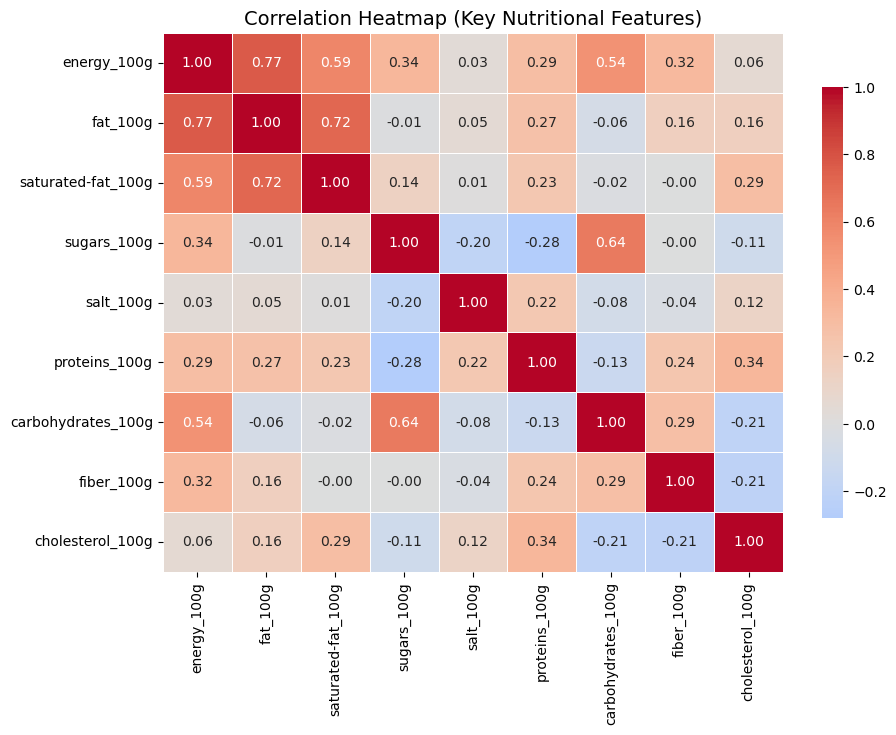

In [131]:
subset_cols = [
    "energy_100g", "fat_100g", "saturated-fat_100g",
    "sugars_100g", "salt_100g", "proteins_100g",
    "carbohydrates_100g", "fiber_100g", "cholesterol_100g"
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    X_scaled[subset_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap (Key Nutritional Features)", fontsize=14)
plt.show()

In [132]:
for col in df_supervised.columns:
    print(col)

brands_tags
countries_en
additives_n
ingredients_from_palm_oil_n
ingredients_that_may_be_from_palm_oil_n
pnns_groups_2
energy_100g
fat_100g
saturated-fat_100g
trans-fat_100g
cholesterol_100g
carbohydrates_100g
sugars_100g
fiber_100g
proteins_100g
salt_100g
vitamin-a_100g
vitamin-c_100g
calcium_100g
iron_100g
grade_num
additives_count
group1_Cereals and potatoes
group1_Composite foods
group1_Fat and sauces
group1_Fish Meat Eggs
group1_Fruits and vegetables
group1_Milk and dairy products
group1_Salty snacks
group1_Sugary snacks
group1_Unknown
group1_cereals-and-potatoes
group1_fruits-and-vegetables
group1_salty-snacks
group1_sugary-snacks
group1_unknown
fat_to_energy
protein_to_energy
sugar_to_carb
has_additives
palm_oil_flag


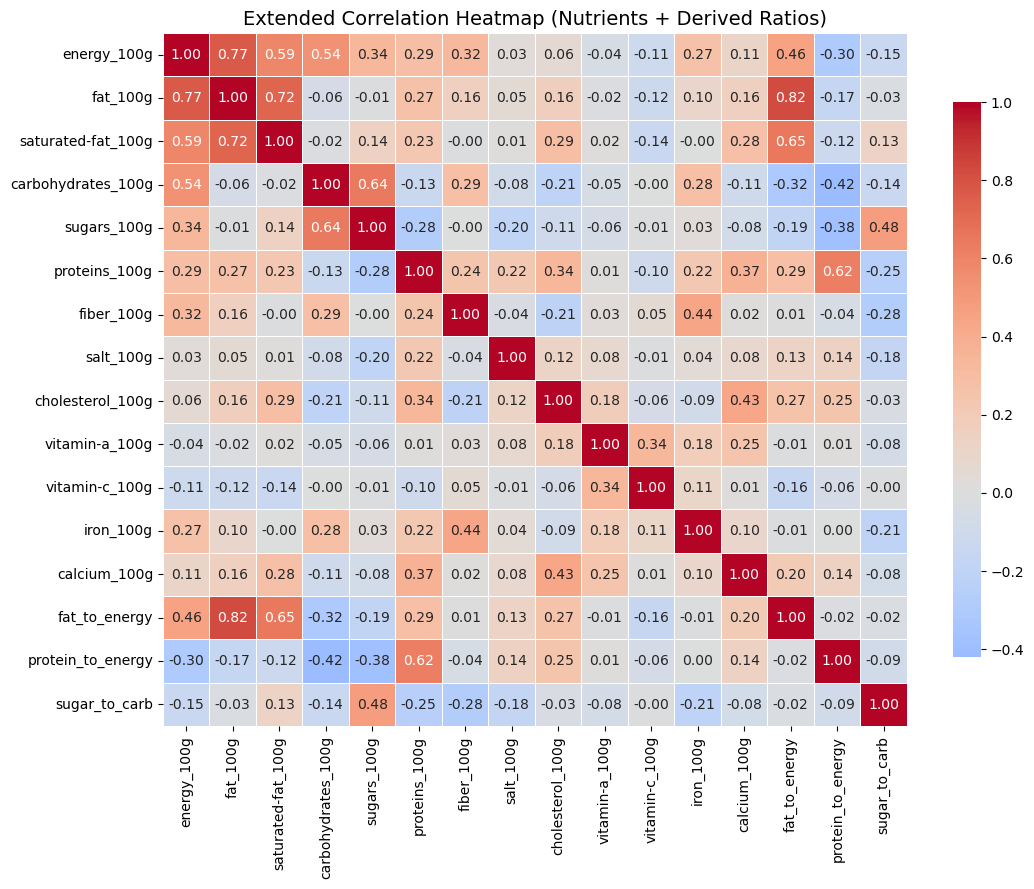

In [133]:
subset_cols = [
    "energy_100g", "fat_100g", "saturated-fat_100g", "carbohydrates_100g", "sugars_100g",
    "proteins_100g", "fiber_100g", "salt_100g", "cholesterol_100g", "vitamin-a_100g",
    "vitamin-c_100g", "iron_100g", "calcium_100g",
    "fat_to_energy", "protein_to_energy", "sugar_to_carb"
]

plt.figure(figsize=(12, 9))
sns.heatmap(
    X_scaled[subset_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"shrink": 0.8}
)
plt.title("Extended Correlation Heatmap (Nutrients + Derived Ratios)", fontsize=14)
plt.show()

In [134]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

cols = ["energy_100g", "fat_100g", "saturated-fat_100g", "fat_to_energy", "protein_to_energy"]

subset = (
    X_scaled[cols]
    .apply(pd.to_numeric, errors="coerce")
    .astype("float64")
)

subset = subset.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")

vif = pd.DataFrame({
    "Feature": subset.columns,
    "VIF": [variance_inflation_factor(subset.values, i) for i in range(subset.shape[1])]
})
vif

,Feature,VIF
0,energy_100g,2.468476
1,fat_100g,5.757058
2,saturated-fat_100g,2.421340
3,fat_to_energy,2.709751
4,protein_to_energy,1.165261


/var/folders/c7/mwgyyxds33bg8rksxm07_r_00000gn/T/ipykernel_16228/2741906330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif, x="VIF", y="Feature", palette="Blues_r")


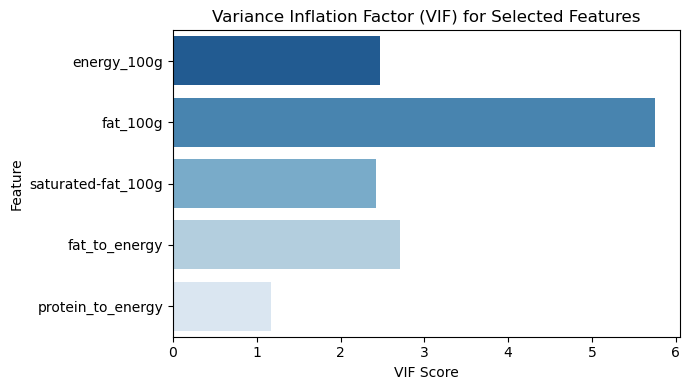

In [151]:
plt.figure(figsize=(7,4))
sns.barplot(data=vif, x="VIF", y="Feature", palette="Blues_r")

plt.title("Variance Inflation Factor (VIF) for Selected Features")
plt.xlabel("VIF Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The extended correlation heatmap shows the linear relationships of the important nutrient features and their constructed ratio features after preprocessing.
Most correlations lie below 0.8, which indicates there is no concerning multicollinearity in the data. The strongest correlations were between fat_100g and fat to energy (r ≈ 0.82) and energy_100g and fat_100g (r ≈ 0.77), which was expected since fat_100g contributes to energy. Other nutrients such as proteins, fiber, and micronutrients (iron, calcium, vitamins A/C) had low or moderate correlations with one another indicating that each also contributed to the model's usefulness by adding unique information. 
The Variance Inflation Factor (VIF) also confirmed these findings quantitatively. All VIF numbers were less than 10 and most were well below 5, indicating no predictors presented concerning redundancy. Fat_100g had the highest VIF of ~5.76, however, it is still within acceptable thresholds for VIF and reflects a substantial biochemical relationship rather than an artifact of the data. Overall, the heatmap and VIF readings support that the nutritional and ratio features selected for modeling can thus be considered stable and useful for the next steps in supervised learning.

### Last Checks Before Modeling

In [135]:
df_supervised.isna().sum().sum()

16981

In [136]:
missing = df_supervised.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

sugar_to_carb        12485
fat_to_energy         2248
protein_to_energy     2248
dtype: int64

In [137]:
ratio_cols = ["sugar_to_carb", "fat_to_energy", "protein_to_energy"]

for col in ratio_cols:
    df_supervised[col] = df_supervised[col].replace([np.inf, -np.inf], np.nan)
    df_supervised[col] = df_supervised[col].fillna(0)
df_supervised[ratio_cols].isna().sum()

/var/folders/c7/mwgyyxds33bg8rksxm07_r_00000gn/T/ipykernel_16228/3505505926.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_supervised[col] = df_supervised[col].replace([np.inf, -np.inf], np.nan)
/var/folders/c7/mwgyyxds33bg8rksxm07_r_00000gn/T/ipykernel_16228/3505505926.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_supervised[col] = df_supervised[col].fillna(0)


sugar_to_carb        0
fat_to_energy        0
protein_to_energy    0
dtype: int64

In [138]:
df_supervised['grade_num'].value_counts(normalize=True)

grade_num
2.0    0.284700
3.0    0.207370
1.0    0.196955
5.0    0.159295
4.0    0.151680
Name: proportion, dtype: float64

In [150]:
df_supervised.shape

(237836, 41)

In [139]:
from sklearn.model_selection import train_test_split

TARGET = "grade_num"
X = df_supervised.drop(columns=[TARGET])
y = df_supervised[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True))

Train shape: (190268, 40)
Test shape: (47568, 40)

Target distribution (train):
grade_num
2.0    0.284698
3.0    0.207371
1.0    0.196954
5.0    0.159296
4.0    0.151681
Name: proportion, dtype: float64


## Data Modeling

In [140]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = Pipeline([
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_log, digits=3))
print(confusion_matrix(y_test, y_pred_log))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== Logistic Regression Results ===
              precision    recall  f1-score   support

         1.0      0.623     0.722     0.669      9369
         2.0      0.601     0.482     0.535     13543
         3.0      0.509     0.454     0.480      9864
         4.0      0.481     0.639     0.549      7215
         5.0      0.716     0.708     0.712      7577

    accuracy                          0.583     47568
   macro avg      0.586     0.601     0.589     47568
weighted avg      0.586     0.583     0.580     47568

[[6760 1882   94  619   14]
 [3770 6524 2833  306  110]
 [ 309 2122 4474 2270  689]
 [  11  263 1015 4610 1316]
 [   1   63  366 1786 5361]]


In this part of my analysis I used a logistic regression model as a baseline and trained it against cleaned and encoded Open Food Facts data, using the parameter class_weight='balanced' to address any issues related to class imbalance. The model trained without issue; however when examining the results of the fitting process there is an indication that the LBFGS algorithm has reached its maximum number of iterations (1,000 iterations) before it converged onto an optimal solution. This is likely a result of the fact that the feature set is very high-dimensional (due to both the one-hot encoding and the many features created from engineering) and that multicollinearity exists within the feature set, therefore it is more difficult to optimise the loss function.

This said, the model is still able to generate predictions in spite of the warning received. The classifications report shows that the overall classification performance of the model was reasonable across the Nutri-Score classes, but there were some classes with lower recall than others.

In [141]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===
              precision    recall  f1-score   support

         1.0      0.974     0.954     0.964      9369
         2.0      0.936     0.960     0.948     13543
         3.0      0.907     0.916     0.911      9864
         4.0      0.905     0.884     0.894      7215
         5.0      0.960     0.949     0.955      7577

    accuracy                          0.936     47568
   macro avg      0.936     0.932     0.934     47568
weighted avg      0.936     0.936     0.936     47568

[[ 8935   372    26    22    14]
 [  223 13004   291    21     4]
 [   13   510  9034   300     7]
 [    4    14   551  6375   271]
 [    0     0    63   325  7189]]


In [142]:
from sklearn.metrics import f1_score

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model
}

for name, model in models.items():
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average='macro')
    print(f"{name}: Macro F1 = {f1:.4f}")

Logistic Regression: Macro F1 = 0.5887
Random Forest: Macro F1 = 0.9343


In [149]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_train_log = log_model.predict(X_train)
y_pred_test_log  = log_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train_log)
test_acc  = accuracy_score(y_test,  y_pred_test_log)

train_f1 = f1_score(y_train, y_pred_train_log, average='macro')
test_f1  = f1_score(y_test,  y_pred_test_log, average='macro')

print("=== Logistic Regression Performance ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Training Macro F1: {train_f1:.4f}")
print(f"Test Macro F1:     {test_f1:.4f}")

=== Logistic Regression Performance ===
Training Accuracy: 0.5891
Test Accuracy:     0.5829
Training Macro F1: 0.5946
Test Macro F1:     0.5887


#### Random Forest

In [143]:
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

train_f1 = f1_score(y_train, y_pred_train, average='macro')
test_f1 = f1_score(y_test, y_pred_test, average='macro')

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Training Macro F1: {train_f1:.4f}")
print(f"Test Macro F1:     {test_f1:.4f}")

Training Accuracy: 0.9999
Test Accuracy:     0.9363
Training Macro F1: 0.9999
Test Macro F1:     0.9343


When evaluating the performance of Random Forest with respect to Logistic Regression, the Random Forest model performs significantly better with respect to accuracy on the macro F1 score with a score of roughly 0.93 on the test set. Whereas, although the Random Forest model outperformed the Logistic Regression model on the test set, Random Forest shows nearly perfect training accuracy (≈1.0) when measured against an approximate test set score of 0.936. Therefore, evidence exists that Random Forest is over-fitted to the training data and does not generalize as effectively to new, previously unseen data.

As highlighted in the Comparison Table, the impediments of Logistic Regression's handling of class imbalance and multi-dimensionality impact the performance of that particular model when compared against the Random Forest model, who has proven to be more able to adapt to those challenges better than Logistic Regression. However, the drawbacks of Random Forest include a significantly higher level of variability and a greater tendency to over-fit, which we will address through the processes of either model tuning and/or regularization.

In [144]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,             
    min_samples_split=5,      
    min_samples_leaf=3,       
    max_features='sqrt',     
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=3, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [145]:
y_pred_tuned = rf_tuned.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")

Accuracy: 0.9111
Macro F1: 0.9080


In [146]:
from sklearn.metrics import accuracy_score, f1_score

# Predictions with the tuned model
y_pred_train = rf_tuned.predict(X_train)
y_pred_test  = rf_tuned.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

# Macro F1
train_f1 = f1_score(y_train, y_pred_train, average='macro')
test_f1  = f1_score(y_test,  y_pred_test,  average='macro')

print("=== Tuned Random Forest Performance ===")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Training Macro F1: {train_f1:.4f}")
print(f"Test Macro F1:     {test_f1:.4f}")

=== Tuned Random Forest Performance ===
Training Accuracy: 0.9537
Test Accuracy:     0.9111
Training Macro F1: 0.9512
Test Macro F1:     0.9080


/var/folders/c7/mwgyyxds33bg8rksxm07_r_00000gn/T/ipykernel_16228/4249263251.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Feature', x='Importance', data=feat_imp, palette='viridis')


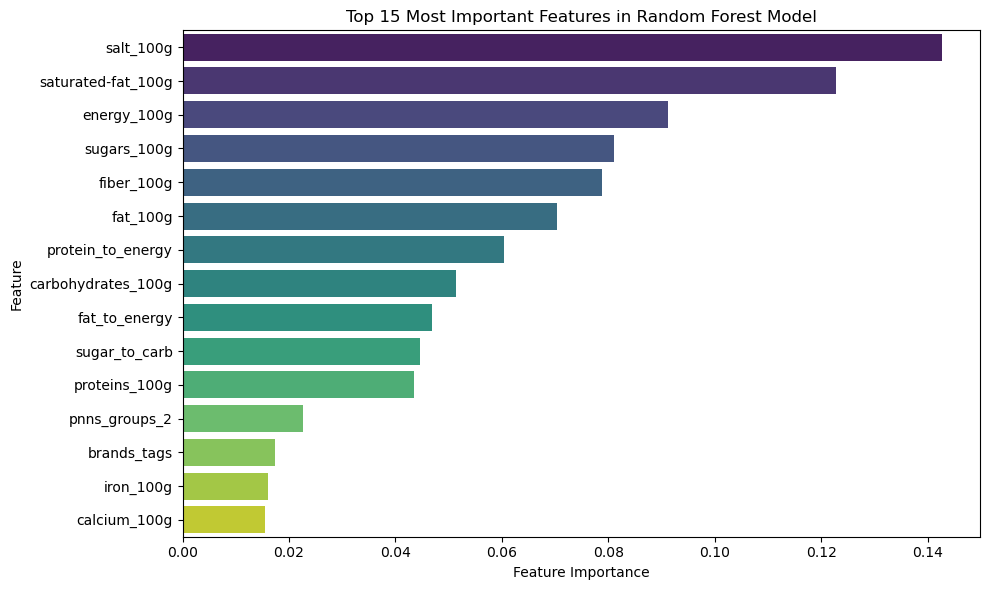

In [147]:
importances = rf_model.feature_importances_
features = X_train.columns
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(y='Feature', x='Importance', data=feat_imp, palette='viridis')
plt.title('Top 15 Most Important Features in Random Forest Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The tuned Random Forest model (depth = 15, min_samples_split = 5, min_samples_leaf = 3, max_features = 'sqrt') significantly reduces overfitting while keeping high performance. Training accuracy drops to ~0.954, and test accuracy stabilizes at ~0.911 with a macro-F1 of ~0.908 — a strong balance between bias and variance.

The updated feature-importance plot confirms that salt, saturated fat, energy, sugars, and fat remain the dominant predictors in the model, matching nutritional intuition and validating the engineered feature space.

In [148]:
df_supervised.to_pickle("df_supervised_clean.pkl")